In [86]:
## 1. Conservative Execution Framework
# Objective:
# In this notebook, I refine the baseline prediction model by introducing a more selective execution framework.
# Instead of reacting to every model signal, I only take risk when model confidence is sufficiently strong and when broader market conditions are supportive.

# Motivation:
# Raw predictive models can generate excessive trading and unstable performance.
# A more disciplined execution process focuses on selectivity, lower turnover, and capital preservation.
# This notebook evaluates whether filtering weak signals and allowing cash exposure improves the robustness of the baseline strategy developed in Notebook 4.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [88]:
## 2. Set project paths Load preprocessed data
project_root = Path.cwd().parent
processed_data_path = project_root / "data" / "processed"
combined_features = pd.read_csv(processed_data_path / "combined_features.csv", index_col=0)
clean_close_prices = pd.read_csv(processed_data_path / "clean_close_prices.csv", index_col=0)

In [89]:
## 3. Rebuild the ML dataset for consistency
spy_returns = clean_close_prices["SPY"].pct_change()
target = (spy_returns.shift(-1) > 0).astype(int)
target.name = "target"
ML_dataset = combined_features.join(target, how="inner")
ML_dataset = ML_dataset.dropna()
ML_dataset.head()

,AAPL_ret,ABBV_ret,ACN_ret,ADBE_ret,AMZN_ret,AVGO_ret,BAC_ret,BRK-B_ret,COST_ret,CRM_ret,...,NVDA_lag5,PEP_lag5,PG_lag5,SPY_lag5,TMO_lag5,UNH_lag5,V_lag5,WMT_lag5,XOM_lag5,target
Date,,,,,,,,,,,,,,,,,,,,,
2018-03-29,0.007809,0.004031,0.041313,0.016656,0.011122,-0.004352,0.020415,0.014288,0.026251,0.030298,...,-0.026996,-0.007357,-0.008177,-0.024997,-0.026437,-0.034153,-0.026213,-0.011794,-0.020522,0
2018-04-02,-0.006556,-0.033703,-0.035961,-0.017586,-0.052061,-0.033821,-0.022674,-0.022458,-0.030144,-0.008598,...,-0.036717,-0.016584,-0.006544,-0.021315,-0.012926,-0.012360,-0.024919,-0.019738,-0.008299,1
2018-04-03,0.010259,-0.009512,0.005474,0.017194,0.014621,0.039968,0.009553,0.015180,-0.000766,0.010321,...,0.049405,0.006218,0.006587,0.027359,0.024579,0.030675,0.031111,0.024350,0.015228,1
2018-04-04,0.019122,0.025941,0.007931,0.042236,0.013304,0.000887,0.009801,0.010861,0.015936,0.025668,...,-0.077552,0.007771,0.018061,-0.017012,-0.014594,-0.005067,-0.026857,-0.016572,-0.004054,1
2018-04-05,0.006935,-0.007854,0.010669,-0.006710,0.029194,-0.002869,0.014726,0.003698,0.003935,-0.003683,...,-0.018491,0.014307,0.013498,-0.002955,-0.003388,0.002478,-0.003493,0.019988,-0.012076,0


In [90]:
## 4. Split ML dataset into "Features" and "Target"
X = ML_dataset.drop(columns="target")
y = ML_dataset["target"]

In [91]:
## 5. Split "Data" into test/train based on Time
split_index = int(len(ML_dataset)*0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [92]:
## 5. Re-train Logistics Regression model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [93]:
## 6. Generate predictions and probability scores
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
probability_df = pd.DataFrame({"actual":y_test, "pred_up_prob":y_prob}, index=y_test.index)
probability_df.head()

Accuracy: 0.511166253101737
              precision    recall  f1-score   support

           0       0.45      0.46      0.45       178
           1       0.56      0.56      0.56       225

    accuracy                           0.51       403
   macro avg       0.51      0.51      0.51       403
weighted avg       0.51      0.51      0.51       403



,actual,pred_up_prob
Date,,
2024-08-23,0,0.605592
2024-08-26,1,0.642548
2024-08-27,0,0.592815
2024-08-28,1,0.547903
2024-08-29,1,0.451468


In [94]:
## 7. Build conservative execution rules
spy_price = clean_close_prices["SPY"]
spy_ma_200 = spy_price.rolling(200). mean()
regime_filter = (spy_price.loc[X_test.index] > spy_ma_200.loc[X_test.index]).astype(int)
set_threshold = 0.55
filtered_signal = ((probability_df["pred_up_prob"] > set_threshold) & regime_filter==1).astype(int)
filtered_signal.head()

Date
2024-08-23    1
2024-08-26    1
2024-08-27    1
2024-08-28    0
2024-08-29    0
dtype: int64

In [95]:
## 8. Convert filtered signals into positions (Must aviod look-ahead bias)
position = filtered_signal.shift(1).fillna(0)
position.head()

Date
2024-08-23    0.0
2024-08-26    1.0
2024-08-27    1.0
2024-08-28    1.0
2024-08-29    0.0
dtype: float64

In [96]:
## 9. Compute strategy returns and benchmark returns
spy_test_returns = spy_returns.loc[X_test.index]
strategy_returns = position * spy_test_returns
benchmark_returns = spy_test_returns.loc[strategy_returns.index]

In [97]:
## 10. Compute cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

In [98]:
## 11. Define performance evaluation functions
def annualized_return(returns, periods_per_year=252):
    total_return = (1 + returns).prod()
    n_periods = len(returns)
    return total_return ** (252 / n_periods) - 1
def annualized_volatility(returns, periods_per_year=252):
    return returns.std() * np.sqrt(periods_per_year)
def sharpe_ratio (returns, periods_per_year=252):
    volatility = annualized_volatility(returns, periods_per_year)
    if volatility == 0:
        return np.nan
    return annualized_return(returns, periods_per_year) / volatility
def max_drawdown(cumulative_returns):
    drawdown = (cumulative_returns - cumulative_returns.cummax()) / cumulative_returns.cummax()
    return drawdown.min()
def hit_rate(returns):
    active_returns = returns[returns != 0]
    if len (active_returns) == 0:
        return np.nan
    return (active_returns > 0).mean()
def exposure_rate(position_series):
    return (position_series != 0).mean()
def turnover_rate(position_series):
    return (position_series).diff().abs().fillna(0).sum()

In [99]:
## 12. Evaluate strategy performance
strategy_metrics = {"Annualized Return": annualized_return(strategy_returns),
                    "Annualized Volatility": annualized_volatility(strategy_returns),
                    "Sharpe Ratio": sharpe_ratio(strategy_returns),
                    "Max Drawdown": max_drawdown(cum_strategy),
                    "Hit Rate": hit_rate(strategy_returns),
                    "Exposure Rate": exposure_rate(position),
                    "Turnover": turnover_rate(position)}

benchmark_metrics = {"Annualized Return": annualized_return(benchmark_returns),
                     "Annualized Volatility": annualized_volatility(benchmark_returns),
                     "Sharpe Ratio": sharpe_ratio(benchmark_returns),
                     "Max Drawdown": max_drawdown(cum_benchmark)}
print("Strategy Metrics:")
for k, v in strategy_metrics.items():
    print(f"{k}: {v:.4f}")

Strategy Metrics:
Annualized Return: 0.0755
Annualized Volatility: 0.0794
Sharpe Ratio: 0.9506
Max Drawdown: -0.0542
Hit Rate: 0.5503
Exposure Rate: 0.4690
Turnover: 34.0000


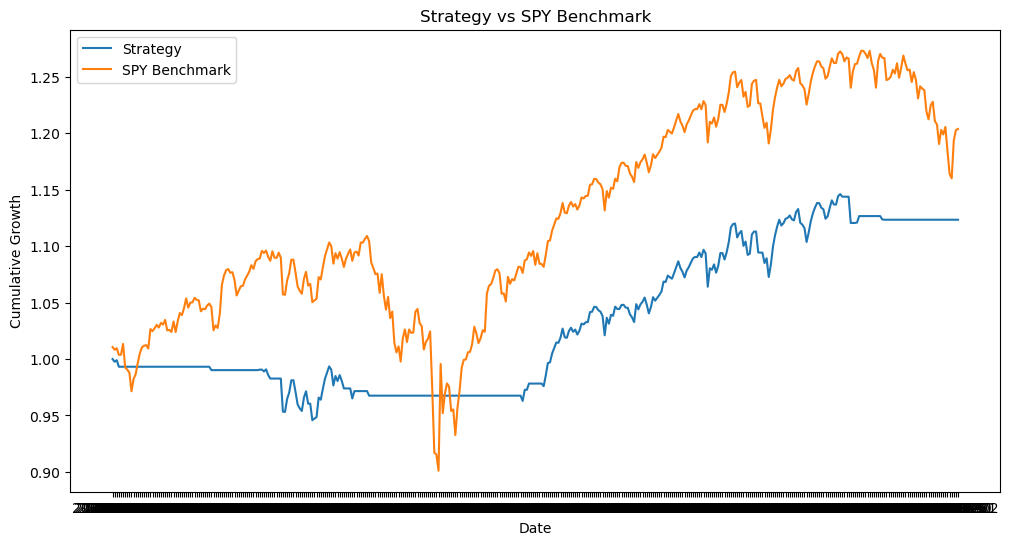

In [100]:
## 13. Visualize cumulative performance
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label="Strategy")
plt.plot(cum_benchmark, label="SPY Benchmark")
plt.legend()
plt.title("Strategy vs SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.show()

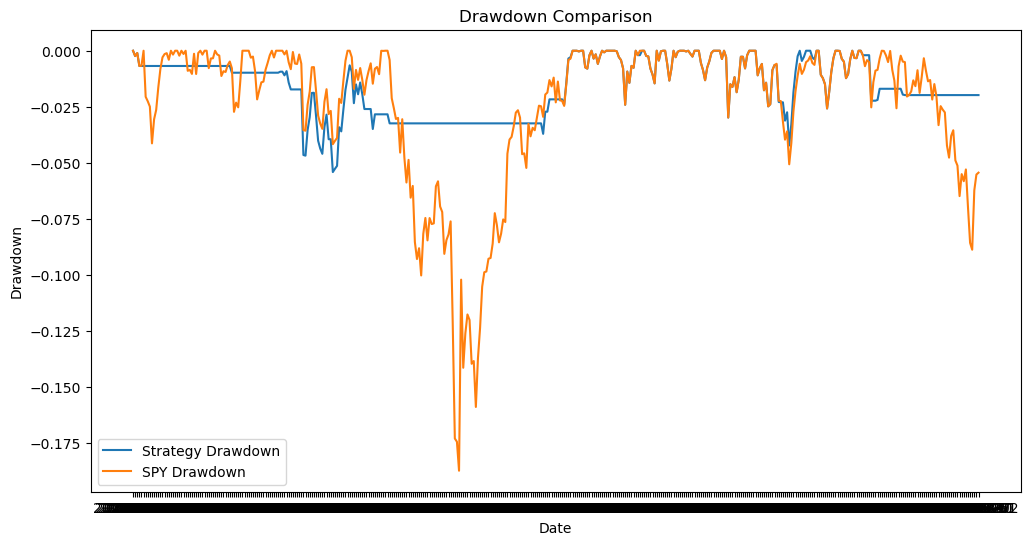

In [101]:
## 14. Visualize drawdown
strategy_drawdown = (cum_strategy - cum_strategy.cummax()) / cum_strategy.cummax()
benchmark_drawdown = (cum_benchmark - cum_benchmark.cummax()) / cum_benchmark.cummax()
plt.figure(figsize=(12, 6))
plt.plot(strategy_drawdown, label="Strategy Drawdown")
plt.plot(benchmark_drawdown, label="SPY Drawdown")
plt.legend()
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

In [102]:
## 14. Conclusion:
# The refined strategy is more selective than the baseline model from Notebook 4.
# By filtering low-confidence predictions and requiring a supportive market regime, the strategy avoids unnecessary trades and allows cash exposure during weaker conditions.
# This produces a more disciplined execution framework and shifts the focus from predicting every move to acting only when conditions are favorable.

In [103]:
ML_dataset.to_csv(processed_data_path / "ML_dataset.csv", index=True)
strategy_returns.to_csv(processed_data_path / "filtered_strategy_returns.csv", index=True)
position.to_csv(processed_data_path / "filtered_positions.csv", index=True)
probability_df.to_csv(processed_data_path / "probability_signals.csv", index=True)